Shape: (15, 640, 368)
calib:  (15, 640, 20) <class 'numpy.complex64'>
Result shape: (15, 640, 368)


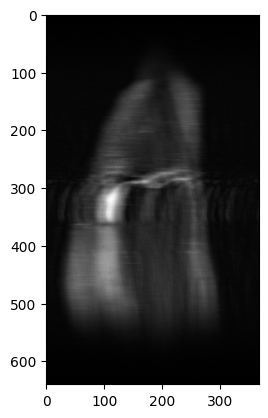

In [14]:
from pygrappa import grappa
import numpy as np
import matplotlib.pyplot as plt
from fastmri.data import transforms as T
import fastmri

slice_kspace = np.load("/home/biswamitra/health/knee_data/test/deconstructed_test/file1000082_014.npy")
ncoils, sx, sy = slice_kspace.shape[:] # Shape is (Coils, Height, Width)
print(f"Shape: {slice_kspace.shape}")
ctr, pd = int(sy/2), 10
# Calibration region: Center of readout (sx/Height)
calib = slice_kspace[:, :, ctr-pd:ctr+pd].copy() 

print("calib: ",calib.shape, type(calib[0][0][0]))
# coil_axis=-1 is default, but our data is (Coils, H, W), so we use coil_axis=0
res = grappa(slice_kspace, calib, kernel_size=(5, 5), coil_axis=0)

# image generated by the GRAPPA technique
print(f"Result shape: {res.shape}")
#visualization
tensor = T.to_tensor(res)
image_data_complex = fastmri.ifft2c(tensor)
image_rss = fastmri.rss(fastmri.complex_abs(image_data_complex),dim=0)
plt.imshow(image_rss,cmap="gray")
plt.show()

Data Shape: (15, 640, 368)
Detected: Sampling is Vertical (Columns). slicing dim 2.
ACS Region found at indices: 177 to 192 (Width: 15)
Running GRAPPA...


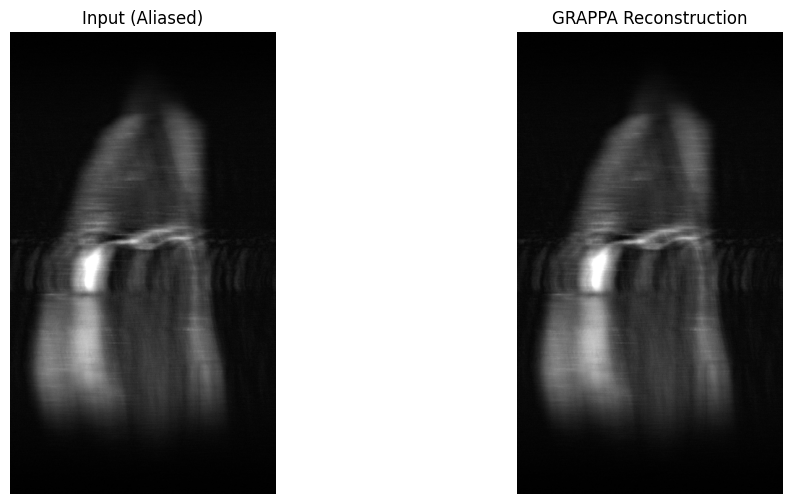

In [10]:
from pygrappa import grappa
import numpy as np
import matplotlib.pyplot as plt
import fastmri
from fastmri.data import transforms as T

# 1. Load Data
file_path = "/home/biswamitra/health/knee_data/test/deconstructed_test/file1000082_014.npy"
slice_kspace = np.load(file_path) # Shape: (Coils, Height, Width)
ncoils, h, w = slice_kspace.shape
print(f"Data Shape: {slice_kspace.shape}")

# 2. DETECT SAMPLING DIRECTION
# We sum energy along axes to see which one has the "holes" (zeros)
# Profile along Height (Dim 1)
profile_h = np.sum(np.abs(slice_kspace), axis=(0, 2))
# Profile along Width (Dim 2)
profile_w = np.sum(np.abs(slice_kspace), axis=(0, 1))

# Normalize profiles
mask_h = profile_h > (np.max(profile_h) * 0.001)
mask_w = profile_w > (np.max(profile_w) * 0.001)

# Logic: The dimension with "gaps" (False values) is the Phase Encoding direction.
# The dimension that is fully solid (True everywhere) is the Frequency Encode direction.
if np.mean(mask_h) < 1.0 and np.mean(mask_w) == 1.0:
    print("Detected: Sampling is Horizontal (Rows). slicing dim 1.")
    pe_axis = 1
    mask_1d = mask_h
elif np.mean(mask_w) < 1.0 and np.mean(mask_h) == 1.0:
    print("Detected: Sampling is Vertical (Columns). slicing dim 2.")
    pe_axis = 2
    mask_1d = mask_w
else:
    # Fallback: Check which axis has the dense center block
    print("Warning: Could not strictly determine axis. Assuming Width (dim 2) based on your image.")
    pe_axis = 2
    mask_1d = mask_w

# 3. EXTRACT ACS (Calibration Data)
# Find the largest contiguous block of 'True' values in the mask
# This identifies the center dense region shown in your mask image.
diffs = np.diff(np.concatenate(([0], mask_1d.astype(int), [0])))
starts = np.where(diffs == 1)[0]
ends = np.where(diffs == -1)[0]

# Get the longest segment (the ACS region)
lengths = ends - starts
longest_idx = np.argmax(lengths)
acs_start = starts[longest_idx]
acs_end = ends[longest_idx]

print(f"ACS Region found at indices: {acs_start} to {acs_end} (Width: {acs_end - acs_start})")

# Slice strictly based on the detected axis
if pe_axis == 1:
    calib = slice_kspace[:, acs_start:acs_end, :].copy()
else:
    calib = slice_kspace[:, :, acs_start:acs_end].copy()

# 4. RUN GRAPPA
# Important: Cast to complex128 for PyGrappa stability
kspace_input = slice_kspace.astype(np.complex128)
calib = calib.astype(np.complex128)

print("Running GRAPPA...")
res = grappa(kspace_input, calib, kernel_size=(5, 5), coil_axis=0)

# 5. VISUALIZATION
def to_image(kspace):
    # Convert k-space to image (RSS)
    tensor = T.to_tensor(kspace)
    image_complex = fastmri.ifft2c(tensor)
    return fastmri.rss(fastmri.complex_abs(image_complex), dim=0).numpy()

img_input = to_image(slice_kspace)
img_grappa = to_image(res)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_input, cmap="gray", vmax=np.max(img_input)*0.8)
ax[0].set_title("Input (Aliased)")
ax[0].axis('off')

ax[1].imshow(img_grappa, cmap="gray", vmax=np.max(img_input)*0.8)
ax[1].set_title("GRAPPA Reconstruction")
ax[1].axis('off')

plt.show()

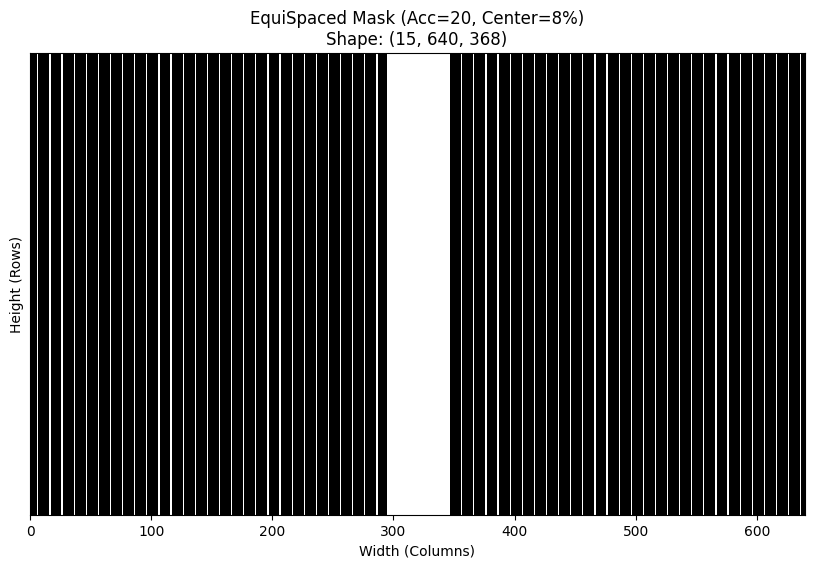

In [12]:
import torch
import matplotlib.pyplot as plt
from fastmri.data.subsample import EquiSpacedMaskFunc

# 1. Setup the Mask Function with your specific parameters
mask_func = EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[10])

# 2. Define a dummy shape (Coils, Height, Width)
# The mask only cares about the last dimension (Width)
data_shape = (15, 640, 368) 

# 3. Generate the mask
# We pass the shape to the function. It returns (mask, num_low_frequencies)
mask_tensor, _ = mask_func(data_shape, seed=42)

# 4. Prepare for plotting
# The mask comes out as shape (1, 1, 368). 
# We squeeze it to 1D (368,) and tile it vertically to make it visible as a 2D image.
mask_1d = mask_tensor.squeeze().numpy()
mask_2d = np.tile(mask_1d, (data_shape[1], 1))

# 5. Plot
plt.figure(figsize=(10, 6))
plt.imshow(mask_2d, cmap='gray', interpolation='nearest', aspect='auto')
plt.title(f"EquiSpaced Mask (Acc=20, Center=8%)\nShape: {data_shape}")
plt.xlabel("Width (Columns)")
plt.ylabel("Height (Rows)")
plt.yticks([]) # Hide Y axis ticks since it's just repeated
plt.show()